# Publication-quality astronomy plots — tutorial

This notebook walks through everything the toolkit offers:

1. [Quick start](#1.-Quick-start)
2. [Figure sizes that match your journal](#2.-Figure-sizes-that-match-your-journal)
3. [The colour-blind-friendly palette](#3.-The-colour-blind-friendly-palette)
4. [Markers and line styles](#4.-Markers-and-line-styles)
5. [Real-world examples](#5.-Real-world-examples)
6. [Switching journals](#6.-Switching-journals)
7. [LaTeX text rendering](#7.-LaTeX-text-rendering)
8. [Saving figures for submission](#8.-Saving-figures-for-submission)

See `README.md` for the full reference documentation.

In [1]:
import sys
sys.path.insert(0, "..")          # so the notebook finds paperplot.py in the repo root

import numpy as np
import matplotlib.pyplot as plt
import paperplot as pp

rng = np.random.default_rng(1)

## 1. Quick start

`pp.set_style(journal)` activates one of the journal styles
(`"mnras"`, `"aanda"`, `"apj"`, `"oja"`), and `pp.subplots()` creates a figure
that is **exactly one column wide** for that journal, with a golden-ratio height.
Because the figure already has the right physical size, you include it in LaTeX
**without any scaling** — so the fonts on the page come out exactly as designed
(~8–9 pt, matching the journal's own text).

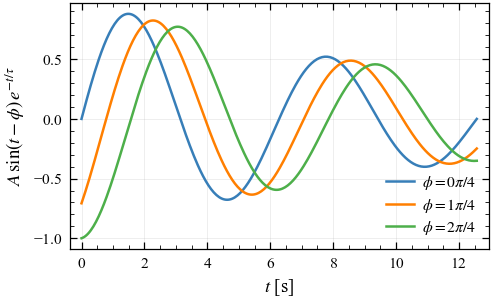

In [2]:
pp.set_style("mnras")

x = np.linspace(0, 4 * np.pi, 300)

fig, ax = pp.subplots()
for i in range(3):
    ax.plot(x, np.sin(x - i * np.pi / 4) * np.exp(-x / 12), label=f"$\\phi = {i}\\pi/4$")
ax.set_xlabel("$t$ [s]")
ax.set_ylabel(r"$A\,\sin(t-\phi)\,e^{-t/\tau}$")
ax.legend()
plt.show()

In LaTeX you would then include it with:

```latex
\begin{figure}
    \includegraphics{myplot.pdf}   % no [width=...] needed!
    \caption{...}
\end{figure}
```

## 2. Figure sizes that match your journal

Why bother? If you make a 6-inch-wide figure and LaTeX squeezes it into an
84 mm column, everything shrinks by ~50% — your 10 pt labels become unreadable
5 pt labels. The fix is to build the figure at its final printed size.

`pp.figsize()` knows the column and full text widths of each journal:

| argument | meaning |
|---|---|
| `width="column"` | one column wide (the default) |
| `width="full"` | full text width (both columns) |
| `width=252.0` | any width in LaTeX points (get yours with `\the\columnwidth`) |
| `fraction=0.5` | a fraction of that width |
| `aspect=1` | height/width of one panel (default: golden ratio ≈ 0.618) |
| `nrows, ncols` | height scales with the subplot grid |

In [3]:
print("one column      :", pp.figsize("column"))
print("full width      :", pp.figsize("full"))
print("half a column   :", pp.figsize("column", fraction=0.5))
print("square panel    :", pp.figsize("column", aspect=1))
print("A&A column      :", pp.figsize("column", journal="aanda"))

one column      : (3.3208800332088004, 2.0524167330839185)
full width      : (6.973848069738481, 4.310075139476229)
half a column   : (1.6604400166044002, 1.0262083665419592)
square panel    : (3.3208800332088004, 3.3208800332088004)
A&A column      : (3.464508094645081, 2.1411837567897978)


`pp.subplots()` accepts the same arguments plus everything `plt.subplots`
takes (`sharex`, `gridspec_kw`, ...). A full-width two-panel figure:

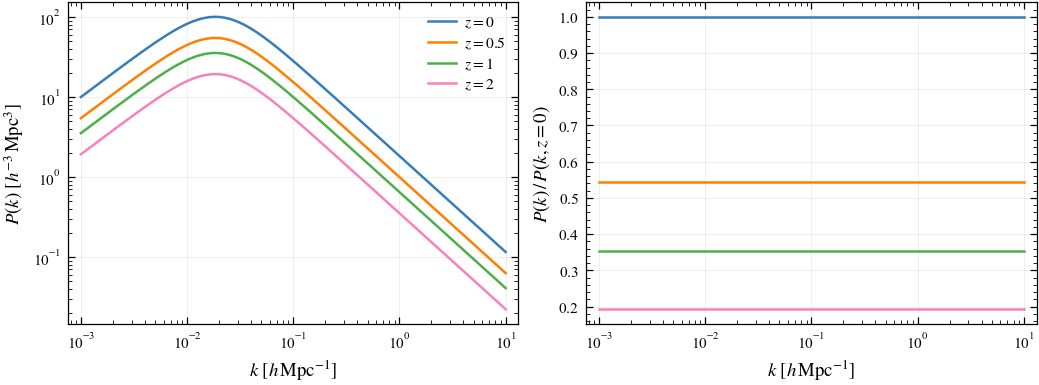

In [4]:
k = np.logspace(-3, 1, 300)

fig, axes = pp.subplots(1, 2, width="full", aspect=0.75, sharex=True)
for z in [0, 0.5, 1, 2]:
    pk = 1e4 * k / (1 + (k / 0.02) ** 2.2) / (1 + z) ** 1.5
    axes[0].loglog(k, pk, label=f"$z = {z}$")
    axes[1].semilogx(k, pk / (1e4 * k / (1 + (k / 0.02) ** 2.2)))
axes[0].set_ylabel(r"$P(k)\ [h^{-3}\,\mathrm{Mpc}^3]$")
axes[1].set_ylabel(r"$P(k)\,/\,P(k, z=0)$")
for ax in axes:
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
axes[0].legend()
plt.show()

## 3. The colour-blind-friendly palette

The default colour cycle is designed so that **any two neighbouring colours
remain distinguishable with the most common forms of colour-vision deficiency**
(deuteranopia and protanopia, ~5% of male readers — MNRAS explicitly asks for
colour-blind-friendly figures).

- **C0–C8** are a colour-blind-safe re-ordering of the ColorBrewer *Set1*
  palette: red and green are pushed far apart in the cycle (C7 and C2), so
  consecutive lines never form the classic problem pair, and adjacent colours
  differ in *lightness* as well as hue.
- **C9–C11** are light companions (from Tableau's *Color Blind 10*): perfect
  for uncertainty bands, reference lines, or de-emphasised data under a
  saturated line of the same hue.

Every colour is available by name via `pp.COLORS`:

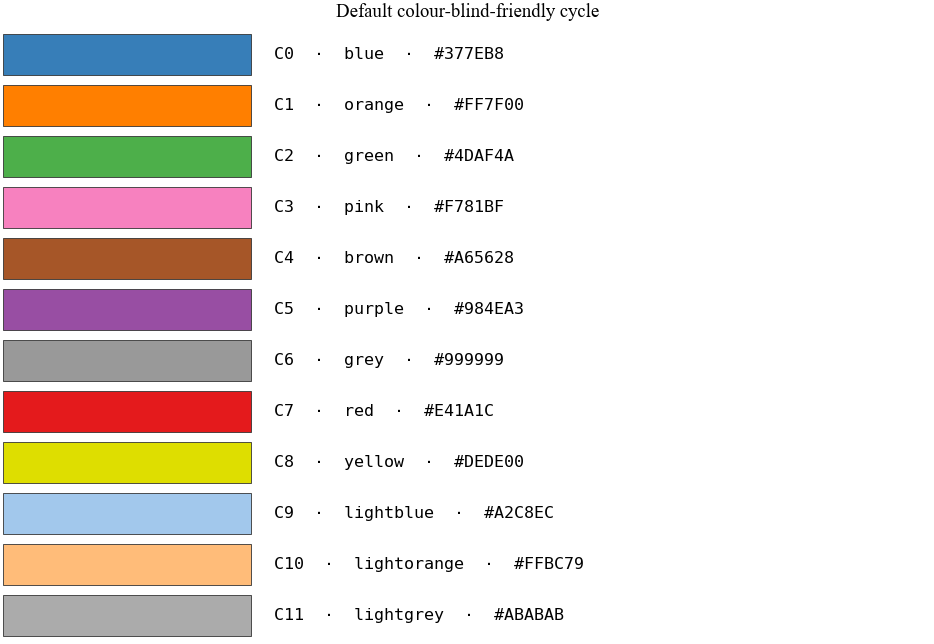

In [5]:
fig = pp.show_colors()
plt.show()

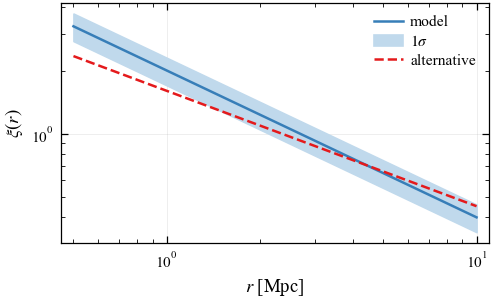

In [6]:
x = np.linspace(0.5, 10, 200)
y = 2 * x ** -0.7

fig, ax = pp.subplots()
ax.plot(x, y, color=pp.COLORS["blue"], label="model")
ax.fill_between(x, 0.85 * y, 1.15 * y,
                color=pp.lighten(pp.COLORS["blue"], 0.7), label=r"$1\sigma$")
ax.plot(x, 1.6 * x ** -0.55, color=pp.COLORS["red"], ls="--", label="alternative")
ax.set_xlabel(r"$r$ [Mpc]")
ax.set_ylabel(r"$\xi(r)$")
ax.loglog()
ax.legend()
plt.show()

`pp.lighten(colour, amount)` and `pp.darken(colour, amount)` create matched
shades — much nicer than `alpha`, because they stay opaque (no colour shifts
where elements overlap, and they print correctly).

An alternative palette, Okabe & Ito (2008), is also included as
`pp.OKABE_ITO` — it is *the* standard recommendation for categorical colours
in scientific figures:

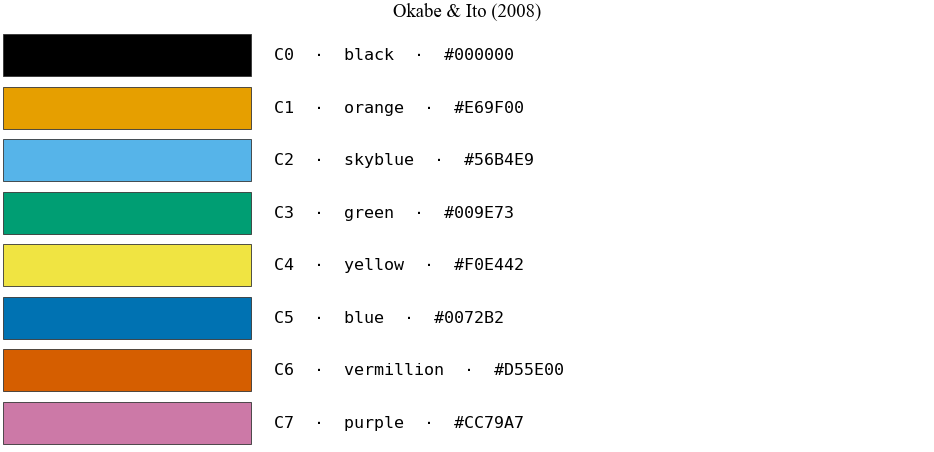

In [7]:
fig = pp.show_colors(pp.OKABE_ITO, title="Okabe & Ito (2008)")
plt.show()

**Rule of thumb:** colour should never be the *only* thing that separates
two curves. Also vary the line style or marker (see next section) — then your
figure survives greyscale printing too.

## 4. Markers and line styles

`pp.MARKERS` is a sequence chosen to stay distinguishable at small (4 pt)
sizes, and `pp.LINESTYLES` provides named dash patterns beyond matplotlib's
four built-ins:

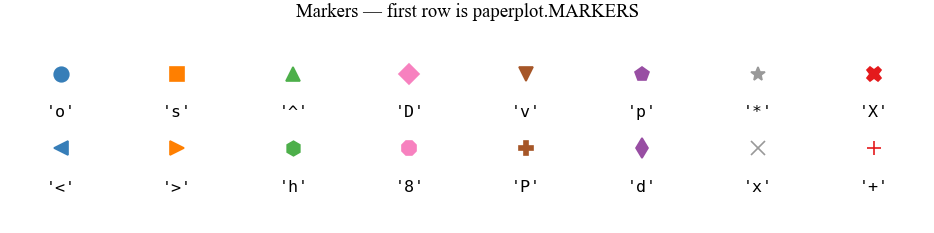

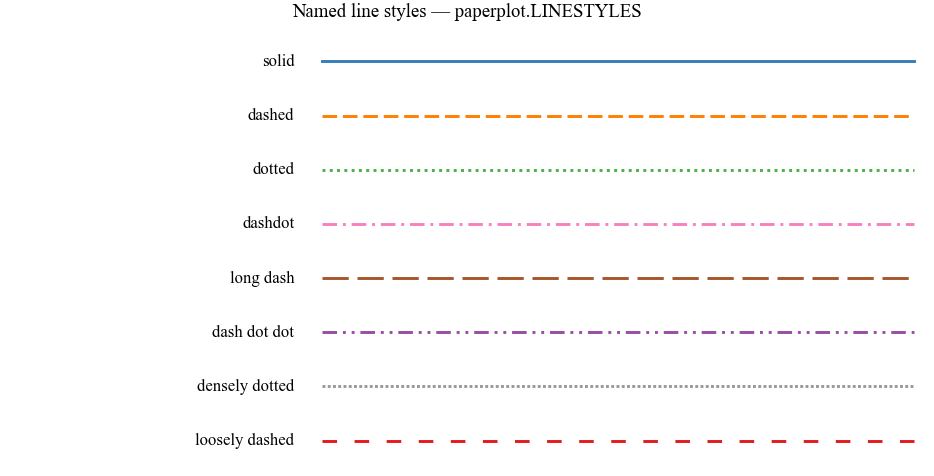

In [8]:
fig = pp.show_markers()
plt.show()
fig = pp.show_linestyles()
plt.show()

### Cycling colours, markers and line styles together

`pp.style_cycler()` builds a property cycle that advances colour, marker
and/or dash pattern *in step* — the redundant encoding mentioned above.
Use `markevery` to avoid a solid wall of markers on dense data:

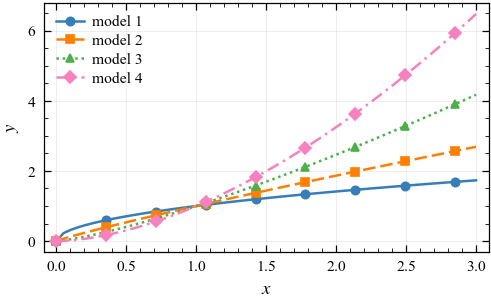

In [9]:
x = np.linspace(0, 3, 60)

fig, ax = pp.subplots()
ax.set_prop_cycle(pp.style_cycler(markers=True, linestyles=True))
for n in range(4):
    ax.plot(x, x ** (0.5 + 0.4 * n), markevery=7, label=f"model {n + 1}")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend()
plt.show()

To apply such a cycle to *all* figures instead of a single axes:

```python
plt.rc("axes", prop_cycle=pp.style_cycler(markers=True))
```

## 5. Real-world examples

### Data with error bars and a fitted model

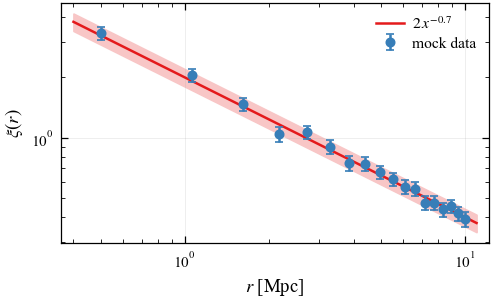

In [10]:
x = np.linspace(0.5, 10, 18)
truth = 2.0 * x ** -0.7
y = truth * rng.normal(1, 0.08, x.size)

fig, ax = pp.subplots()
ax.errorbar(x, y, yerr=0.08 * truth, fmt="o", color=pp.COLORS["blue"],
            label="mock data", zorder=3)
xf = np.linspace(0.4, 11, 200)
ax.plot(xf, 2.0 * xf ** -0.7, color=pp.COLORS["red"], label=r"$2\,x^{-0.7}$")
ax.fill_between(xf, 1.8 * xf ** -0.7, 2.2 * xf ** -0.7,
                color=pp.lighten(pp.COLORS["red"], 0.75), zorder=0)
ax.loglog()
ax.set_xlabel(r"$r$ [Mpc]")
ax.set_ylabel(r"$\xi(r)$")
ax.legend()
plt.show()

### Comparing distributions

Use `histtype="step"` for overlapping histograms — filled histograms hide
each other, stepped ones don't:

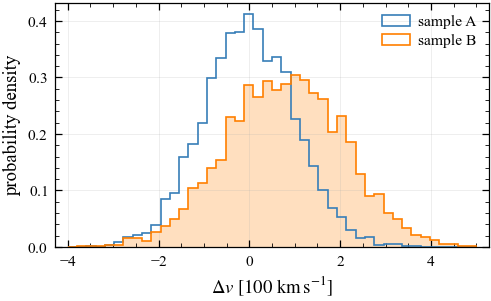

In [11]:
a = rng.normal(0.0, 1.0, 4000)
b = rng.normal(0.8, 1.3, 4000)
bins = np.linspace(-4, 5, 45)

fig, ax = pp.subplots()
ax.hist(a, bins, histtype="step", lw=1.2, label="sample A", density=True)
ax.hist(b, bins, histtype="step", lw=1.2, label="sample B", density=True)
ax.hist(b, bins, color=pp.lighten(pp.COLORS["orange"], 0.75),
        density=True, zorder=0)
ax.set_xlabel(r"$\Delta v\ [100\ \mathrm{km\,s^{-1}}]$")
ax.set_ylabel("probability density")
ax.legend()
plt.show()

### Images with a colour bar

The default colormap is `viridis` (perceptually uniform and colour-blind
safe). For images, a square panel usually looks best — pass `aspect=1`.
For astronomical images you typically also want `origin="lower"`:

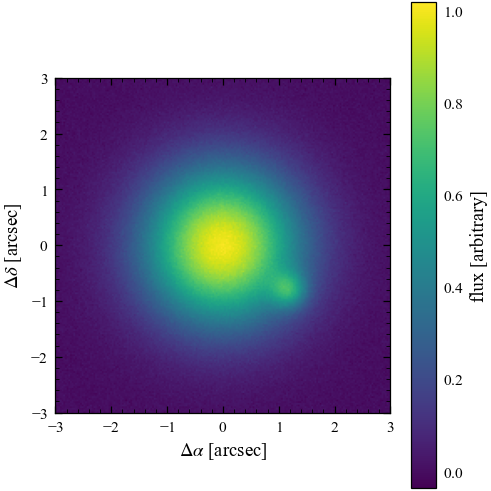

In [12]:
yy, xx = np.mgrid[-3:3:200j, -3:3:200j]
img = np.exp(-(xx**2 + yy**2) / 2) + 0.35 * np.exp(-((xx - 1.2)**2 + (yy + 0.8)**2) / 0.1)
img += rng.normal(0, 0.01, img.shape)

fig, ax = pp.subplots(aspect=1)
im = ax.imshow(img, extent=[-3, 3, -3, 3], origin="lower")
fig.colorbar(im, ax=ax, label="flux [arbitrary]")
ax.set_xlabel(r"$\Delta\alpha$ [arcsec]")
ax.set_ylabel(r"$\Delta\delta$ [arcsec]")
ax.grid(False)
plt.show()

## 6. Switching journals

The four styles share one visual language — same fonts, colours, tick and
legend settings — and differ only in the default figure width, so your plots
stay consistent across papers. Switch with a single call:

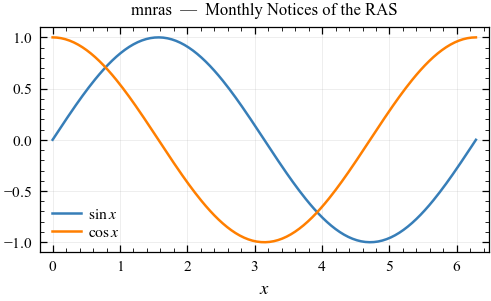

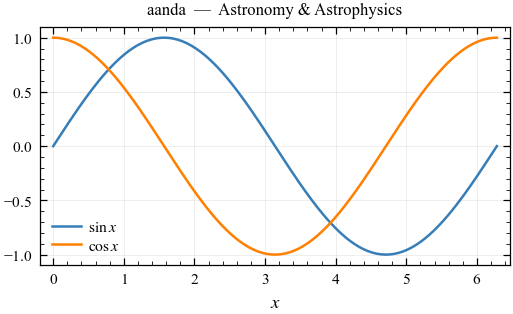

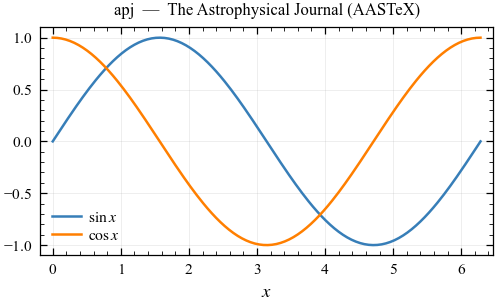

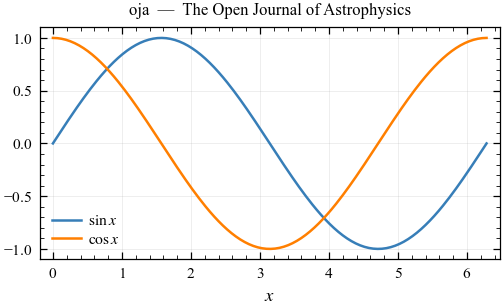

In [13]:
x = np.linspace(0, 2 * np.pi, 200)

for journal in ["mnras", "aanda", "apj", "oja"]:
    pp.set_style(journal)
    fig, ax = pp.subplots()
    ax.plot(x, np.sin(x), label=r"$\sin x$")
    ax.plot(x, np.cos(x), label=r"$\cos x$")
    ax.set_title(f"{journal}  —  {pp.JOURNALS[journal]['name']}", fontsize=8)
    ax.set_xlabel("$x$")
    ax.legend()
    plt.show()

pp.set_style("mnras")   # back to default for the rest of the notebook

The differences are subtle (a few mm of width) but they matter: each
figure drops into its journal's column at 100% scale.

You can also override any rcParam per journal or per session:

```python
pp.set_style("mnras", grid=False)                    # no grid
pp.set_style("mnras", **{"font.size": 10})           # bigger fonts
```

## 7. LaTeX text rendering

By default the styles use matplotlib's built-in *mathtext* with STIX fonts —
Times-compatible maths that works everywhere, with no LaTeX installation
required.

If you have LaTeX installed and want pixel-perfect consistency with your
manuscript (including `\textrm`, custom macros, proper kerning), turn on full
LaTeX rendering:

```python
pp.set_style("mnras", usetex=True)
```

This uses the `newtx` font packages (the modern Times fonts — MNRAS and A&A
are typeset in Times). It needs `latex`, `dvipng` and `ghostscript` on your
`PATH`, and rendering is noticeably slower — a good workflow is to develop
with `usetex=False` and flip it on for the final version.

## 8. Saving figures for submission

The styles already save with sensible settings: PDF (vector) by default,
450 dpi for rasterised elements (journals ask for ≥ 300–400 dpi), tight
bounding box, and TrueType fonts embedded (`pdf.fonttype: 42` — avoids the
Type-3 font errors journal submission systems complain about).

`pp.savefig` writes several formats in one call — e.g. a PDF for the
manuscript and a PNG to paste into slides or collaboration chats:

['/var/folders/49/gftfyhj56zs1lz_zs90jcw000000gn/T/tmprks84we_/figure1.pdf',
 '/var/folders/49/gftfyhj56zs1lz_zs90jcw000000gn/T/tmprks84we_/figure1.png']

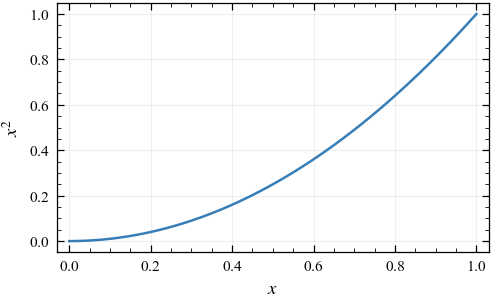

In [14]:
import tempfile, os
outbase = os.path.join(tempfile.mkdtemp(), "figure1")

fig, ax = pp.subplots()
ax.plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50) ** 2)
ax.set_xlabel("$x$")
ax.set_ylabel("$x^2$")

pp.savefig(outbase, fig=fig, formats=("pdf", "png"))

**Per-journal notes**

| journal | accepted figure formats | notes |
|---|---|---|
| MNRAS | EPS preferred, PDF/TIFF fine | ≥ 400 dpi raster, ~8 pt lettering, colour-blind friendly required |
| A&A | PDF/EPS | figures 88 mm (column) or 170–180 mm (page) wide |
| ApJ / AAS | PDF/EPS/PNG | vector strongly preferred |
| OJA | PDF (arXiv-ready) | whatever compiles on arXiv works |

If a journal insists on EPS, save EPS *and* check it — transparency is not
supported in EPS, so replace `alpha=` with `pp.lighten()` shades (another
reason they are the better habit).

That's it — happy plotting! See `README.md` for the full reference.